<img src="https://userweb.fct.unl.pt/~jmc.xavier/MSII/iLogos/logo_novafct.png" width="200">

# Departamento de Engenharia Mecânica e Industrial
## Mecânica dos Sólidos II

## Tensões principais

### Problema 7

Três forças estão aplicadas numa viga de secção retangular 100$\times$150 mm, como se indica na figura.

**a)** Determine a distribuição de tensões normais na secção que contém os pontos H e K, representando a posição da linha neutra e os valores máximos e mínimos da tensão normal.

**b)** Determine o tensor das tensões em relação ao referencial indicado nos pontos H e K.

**c)** Calcule o valor das tensões principais e da tensão tangencial máxima no ponto H.

<img src="https://userweb.fct.unl.pt/~jmc.xavier/MSII/Notebooks/Au07/P7/MSII_Au07_P7.png"
width="500">


### Resolução

In [26]:
import numpy as np
import sympy as sy
from sympy.solvers import solve
import matplotlib.pyplot as plt
import matplotlib.patches as patches

import os

cor = '2'
if cor == '1':
    plt.rcParams['axes.facecolor'] = (.15, .15, .15)
    plt.rcParams['figure.facecolor'] = (.15, .15, .15)
    plt.rcParams['font.family'] = 'monospace'
    plt.rcParams['font.size'] = 18
    # plt.rcParams['text.usetex'] = True
    params = {"ytick.color" : (.8, .8, .8),
              "xtick.color" : (.8, .8, .8),
              "grid.color" : (.2, .2, .2),
              "text.color" : (.7, .7, .7),
              "axes.labelcolor" : (.8, .8, .8),
              "axes.edgecolor" : (.15, .15, .15)}
else:
    plt.rcParams['axes.facecolor'] = (.7, .7, .7)
    plt.rcParams['figure.facecolor'] = (.7, .7, .7)
    plt.rcParams['font.family'] = 'monospace'
    plt.rcParams['font.size'] = 18
    # plt.rcParams['text.usetex'] = True
    params = {"ytick.color" : (.1, .1, .1),
              "xtick.color" : (.1, .1, .1),
              "grid.color" : (.2, .2, .2),
              "text.color" : (.1, .1, .1),
              "axes.labelcolor" : (.1, .1, .1),
              "axes.edgecolor" : (.15, .15, .15)}
plt.rcParams.update(params)

# data structure, units: N, mm, MPa

class varin: pass

d = varin()

d.tub_b = 100.*1e-3  # unit: m
d.tub_h = 150.*1e-3 # unit: m
d.x1 = 375.e-3 # unit: m
d.x2 = 175.e-3 # unit: m
d.yK = 125.e-3 # unit: m
d.x_Py = 100.e-3 # unit: m
d.y_Py = 75.e-3 # unit: m
d.Px = 107.*1e3 # unit: N/m
d.Py = 13.*1e3 # unit: N/m
d.Pz = 9.*1e3 # unit: N/m


#### **a)** Determine a distribuição de tensões normais na secção que contém os pontos H e K, representando a posição da linha neutra e os valores máximos e mínimos da tensão normal.

#### Sistema força-binário equivalente

- Esforço axial, $N$

\begin{equation*}
N= - P_x
\end{equation*}

In [27]:
N = -d.Px
print(f'N = {N:.1f} [N]')

N = -107000.0 [N]


- Esforço transverso na direção $y$, $V_y$

\begin{equation*}
V_y = - P_y
\end{equation*}

In [28]:
Vy = -d.Py
print(f'Vy = {Vy:.1f} [N]')

Vy = -13000.0 [N]


- Esforço transverso na direção $z$, $V_z$

\begin{equation*}
V_z = P_z
\end{equation*}

In [29]:
Vz = d.Pz
print(f'Vz = {Vz:.1f} [N]')

Vz = 9000.0 [N]


- Momento resultante das forças segundo o eixo $x$, $M_x(\equiv T)$

Apenas as forças ortogonais a $x$ exercem momento torsor,

\begin{equation*}
T = 0
\end{equation*}

In [30]:
T = 0
print(f'T = {T:.1f} [N.m]')

T = 0.0 [N.m]


- Momento fletor em torno do eixo $y$, $M_y$

Por definição de momento de uma força, só exercem momento de flexão em relação ao eixo $y$, as forças que são coplanares com o plano $x-z$ que lhe é perpendicular. Contudo, neste caso, apenas a força $P_z$ contribui para $M_y$:

\begin{equation*}
M_y= - P_z \cdot x_L
\end{equation*}

com

- $\vec{r}_{\vec{P_z}} = x_L~\vec{\imath} ~\wedge~ \vec{P}_z = P_z~\vec{k}  \quad\therefore\quad -P_z x_L~\vec{\jmath}$

In [31]:
My = -d.x1*d.Pz
print(f'My = -({d.x1:.3f}){d.Pz:.1f} = {My:.1f} [N.m]')

My = -(0.375)9000.0 = -3375.0 [N.m]


- Momento fletor em torno do eixo $z$, $M_z$

As forças de exercem momento em relação ao eixo $z$ são as forças contidas no plano $x-y$, $P_x$, $P_y$:

\begin{equation*}
M_z = - P_y x_L
\end{equation*}

com

- $\vec{r}_{\vec{P_x}} = h/2~\vec{\jmath} ~\wedge~ \vec{P}_x = P_x~\vec{\imath} \quad\therefore\quad - P_x (h/2)~\vec{k}$

In [32]:
Mz = -(d.x1-d.x_Py)*d.Py
print(f'Mz = -({d.x1-d.x_Py:.3f}){d.Py:.1f} = {Mz:.1f} [N.m]')

Mz = -(0.275)13000.0 = -3575.0 [N.m]


- Área da secção

In [33]:
A = d.tub_b*d.tub_h
print(f'A = {d.tub_b:.3f}x{d.tub_h:.3f} = {A:.3e} [m^2]')

A = 0.100x0.150 = 1.500e-02 [m^2]


- Momento de inércia em relação ao eixo $z$, $I_z$

Nota: na expressão $I_i = bh³/12$, a dimensão ao cubo ($h³$) é sempre uma dimensão perpendicular ao eixo em análise $i$.

In [34]:
def irect(b,h): return b*h**3/12

Iz = irect(d.tub_b,d.tub_h)
print(f'Iz = {Iz:.3e} [m^4]')

Iz = 2.812e-05 [m^4]


- Momento de inércia em relação ao eixo $y$, $I_y$

In [35]:
Iy = irect(d.tub_h,d.tub_b)
print(f'Iy = {Iy:.3e} [m^2]')

Iy = 1.250e-05 [m^2]


#### Esforço combinado

Neste cenário de carregamento excêntrico, pelo princípio de Saint-Venant, as tensões normais numa secção suficientemente afastada das extremidades da barra (devido a efeito de concentração de tensões) podem ser calculadas, atendendo ainda ao princípio da sobreposição, por:

\begin{equation*}
\sigma_{xx} = -\frac{|N|}{A} + \frac{|M_z|}{I_z}y - \frac{|M_y|}{I_y} z
\end{equation*}

De notar que o momento fletor $M_z$ é positivo, contudo o momento fletor $M_y$ é negativo. Além disso o esforço axial é de compresssão.

In [36]:
y, z, sigx = sy.symbols('y z sigx')

eqsigx = -np.abs(N/A) + np.abs(Mz)/Iz*y - np.abs(My)/Iy*z
Eq = sigx - eqsigx
print(f'Eq = {Eq}')
sigxx = solve(Eq,sigx)[0]
print(f'sigxx(y,z)  = {sigxx*1e-6} [MPa]')



Eq = sigx - 127111111.111111*y + 270000000.0*z + 7133333.33333333
sigxx(y,z)  = 127.111111111111*y - 270.0*z - 7.13333333333333 [MPa]


In [37]:
yzfun = solve(sigxx,y)[0]
print(f'y = {yzfun} (recta geométrica do eixo neutro) [m]')
print(f'z = {solve(sigxx,z)[0]} (recta geométrica do eixo neutro) [m]')

y = 2.12412587412588*z + 0.0561188811188811 (recta geométrica do eixo neutro) [m]
z = 0.470781893004115*y - 0.0264197530864197 (recta geométrica do eixo neutro) [m]


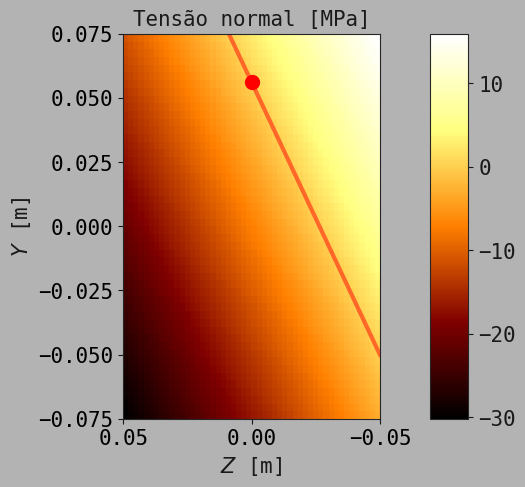

In [38]:
from mpl_toolkits.axes_grid1 import make_axes_locatable
from matplotlib.patches import Rectangle

zsiz = np.linspace(d.tub_b/2,-d.tub_b/2)
ysiz = np.linspace(d.tub_h/2,-d.tub_h/2)
Z, Y = np.meshgrid(zsiz, ysiz)

def tensnormal(y2,z2):
    return sigxx.subs({(y,y2),(z,z2)}) #- eval_NAB/A - eval_MzAB/Iz*y + eval_MyAB/Iy*z

SxxMap = np.zeros(np.shape(Z))
for i in range(0,len(ysiz)):
    for j in range(0,len(zsiz)):
        SxxMap[i,j] = tensnormal(ysiz[i],zsiz[j])

zplo = zsiz
yplo = np.zeros(len(zplo))
for i in range(0,len(zplo)):
    yplo[i] = yzfun.subs(z,zplo[i])

fzp = 15
# Visualizacao u1(X1,X2,X3,t1)
fig = plt.figure(figsize=(10, 5))
ax  = plt.gca()
ttl = plt.title('Tensão normal [MPa]',fontsize=15)
ttl.set_position([0.5, 1.05])
plt.ylim([-1.*d.tub_h/2,1.*d.tub_h/2])
plt.ylabel(r'$Y$ [m]',fontsize=fzp)
plt.xlabel(r'$Z$ [m]',fontsize=fzp)
im = ax.imshow(SxxMap*1e-6, extent=[d.tub_b/2, -d.tub_b/2, -d.tub_h/2,d.tub_h/2], cmap="afmhot")
plt.plot(zplo,yplo,'r-',linewidth=3,alpha=0.5)
ax.plot(0,yzfun.subs(z,0),'or',markersize=10)
plt.xticks(color ='k', size=fzp)
plt.yticks(color ='k', size=fzp)
divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="15%", pad=0.5)
cbar = plt.colorbar(im, cax=cax, orientation = "vertical")
cbar.ax.tick_params(labelsize=fzp)
plt.show()

In [39]:
ymax_, zmax_ = d.tub_h/2, -d.tub_b/2
sigmax_ = tensnormal(ymax_,zmax_)
print(f'sig.max (T) :: (y = {ymax_}, z = {zmax_}) :: {sigmax_*1e-6:.2f} [MPa]')

ymin_, zmin_ = -d.tub_h/2, d.tub_b/2
sigmin_ = tensnormal(ymin_,zmin_)
print(f'sig.min (C) :: (y = {ymin_}, z = {zmin_}) :: {sigmin_*1e-6:.2f} [MPa]')

sig.max (T) :: (y = 0.075, z = -0.05) :: 15.90 [MPa]
sig.min (C) :: (y = -0.075, z = 0.05) :: -30.17 [MPa]


#### **b)**  Determine o tensor das tensões em relação ao referencial indicado nos pontos H e K.

#### Ponto H

- Tensão normal em H

In [40]:
yH, zH = d.tub_h/2, 0
sigH = tensnormal(yH, zH)
print(f'sig.H :: (y = {yH:.3f}, z = {zH:.3f}) :: {sigH*1e-6:.2f} [MPa]')

sig.H :: (y = 0.075, z = 0.000) :: 2.40 [MPa]


- Tensão de corte em H devida a $V_z$

\begin{equation*}
\tau_{xz}^H(V_z) = \frac{|V_z|Q_y}{I_yt}
\quad\wedge\quad Q_y = \int_A^* z\,\mathrm{d}A = A^*\overline{z} = \sum_i A_i^*\overline{z}_i
\end{equation*}

de notar que o ponto H é na superfície horizontal da viga pelo que: $\tau_{xy} = \tau_{yz} =0$.

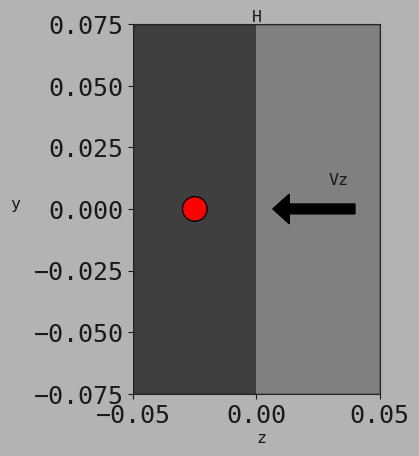

In [41]:
# Define the dimensions of the rectangle
length, width = d.tub_b, d.tub_h  # in m
# Create a figure and axis
fig, ax = plt.subplots()
# Calculate the coordinates of the center of the figure
center_z, center_y = 0, 0
# Create a rectangle patch for the entire shape, centered within the specified range
rect = patches.Rectangle((-length / 2, -width / 2), length, width, linewidth=1, edgecolor='black', facecolor='grey')
ax.add_patch(rect)
# Create a rectangle patch for the shaded area (half of the horizontal size), centered within the specified range
shaded_rect = patches.Rectangle((-length / 2, -width / 2), length / 2, width, facecolor='black', alpha=0.5)
ax.add_patch(shaded_rect)
# Add labels for the y and z coordinates
ax.text(-length / 2 - 0.05, 0, 'y', fontsize=12)
ax.text(0, -width / 2 - 0.02, 'z', fontsize=12)
# Create an arrow for the vector along the z-axis
arrow = patches.Arrow(center_z+length/2.5, center_y, -length/3, 0, width=0.02, edgecolor='black', facecolor='black')
ax.add_patch(arrow)
# Add the label "Vz" near the arrow
ax.text(center_z + length/3., 0.01, 'Vz', fontsize=12, horizontalalignment='center')
# Add "H" at the top of the rectangular shape
ax.text(center_z, width / 2 + 0.001, 'H', fontsize=12, horizontalalignment='center')
# Create a circle at centroid of the half region
circle = patches.Circle((center_z-length/4, center_y), 0.005, edgecolor='black', facecolor='red')
ax.add_patch(circle)
# Set the aspect ratio to be equal to represent the dimensions accurately
ax.set_aspect('equal', adjustable='box')
# Set the axis limits to have the origin at the center of the specified range
ax.set_xlim(-length / 2, length / 2)
ax.set_ylim(-width / 2, width / 2)
# Show the plot
plt.show()


In [42]:
Ay_H = d.tub_b/2*d.tub_h
print(f'Ay_H = {d.tub_b/2:.3f}x{d.tub_h:.3f} = {Ay_H:.3e} [m²]')
z_H = d.tub_b/2/2
print(f'z_H = {z_H:.3e} [m]')
Qy_H = Ay_H*z_H
print(f'Qy_H = {Qy_H:.3e} [m³]')
tauxz_Vz_H = np.abs(Vz)*Qy_H/Iy/d.tub_h
print(f'::\n|Vz| = {Vz:.1f} [N]')
print(f'Qy = {Qy_H:.3e} [m³]')
print(f'Iy = {Iy:.3e} [m⁴]')
print(f't  = {d.tub_h:.3e} [m]')
print(f'>>> Vz = {np.abs(Vz)} :: tauxz_Vz_H  = {tauxz_Vz_H*1e-6:.3f} [MPa]')

Ay_H = 0.050x0.150 = 7.500e-03 [m²]
z_H = 2.500e-02 [m]
Qy_H = 1.875e-04 [m³]
::
|Vz| = 9000.0 [N]
Qy = 1.875e-04 [m³]
Iy = 1.250e-05 [m⁴]
t  = 1.500e-01 [m]
>>> Vz = 9000.0 :: tauxz_Vz_H  = 0.900 [MPa]


- Tensor das tensões no ponto H:

\begin{equation*}
[\sigma]_{H} =
\begin{bmatrix}
\sigma_{xx} & \tau_{xy} & \tau_{xz} \\
\tau_{xy} & \sigma_{yy} & \tau_{yz} \\
\tau_{xz} & \tau_{yz} & \sigma_{zz}
\end{bmatrix} = 
\begin{bmatrix}
\sigma_{xx} & 0 & \tau_{xz} \\
0 & 0 & 0 \\
\tau_{xz} & 0 & 0
\end{bmatrix}
\end{equation*}

onde,

\begin{equation*}
[\sigma]_H = 
\begin{bmatrix}
\left(-\displaystyle\frac{|N|}{A} + \displaystyle\frac{|M_z|}{I_z}y_H - \displaystyle\frac{|M_y|}{I_y} z_H\right) & 0 & \displaystyle\frac{|V_z|Q_y}{I_yt} \\
0 & 0 & 0 \\
\displaystyle\frac{|V_z|Q_y}{I_yt}  & 0 & 0
\end{bmatrix}
\quad\textrm{[MPa]}
\end{equation*}

In [43]:
np.set_printoptions(precision=4)

def tenstens(s11,s12,s13,s22,s23,s33):
    return np.array([[s11,s12,s13],[s12,s22,s23],[s13,s23,s33]], np.float64)

ttH = tenstens(sigH,0,tauxz_Vz_H,0,0,0)
print(f"ttH :: \n {np.array2string(ttH*1e-6, precision=2, floatmode='fixed')} [MPa]")

ttH :: 
 [[2.40 0.00 0.90]
 [0.00 0.00 0.00]
 [0.90 0.00 0.00]] [MPa]


#### Ponto K

- Tensão normal em K

In [44]:
yK, zK = d.yK-d.tub_h/2,  -d.tub_b/2
sigK = tensnormal(yK, zK)
print(f'sig.K :: (y = {yK:.3f}, z = {zK:.3f}) :: {sigK*1e-6:.2f} [MPa]')

sig.K :: (y = 0.050, z = -0.050) :: 12.72 [MPa]


- Tensão de corte devida ao esforço transverso $V_y$

Recorrendo ao formulário da expressão da tensão de corte em relação ao esforço transverso (de notar que nesta expressão o valor de $V$ é considerado positivo de acordo com o sistema de coordenadas escolhido):

\begin{equation*}
\tau_{xy}^K(V_y) = -\frac{|V_y|Q_z}{I_zt}
\quad\wedge\quad Q_z = \int_A^* y\,\mathrm{d}x = A^*\overline{y} = \sum_i A_i^*\overline{y}_i
\end{equation*}

O sentido negativo para a tensão de corte $\tau_{xy}^K(V_y)$, justifica-se pelo facto de haver um carrregamento vertical $P_y$ no sentido negativo do eixo $y$. De notar que o ponto K é na superfície horizontal da viga pelo que: $\tau_{xz} = \tau_{yz} =0$.

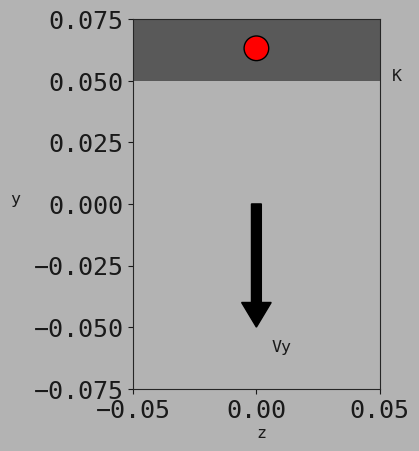

In [45]:
# Create a figure and axis
fig, ax = plt.subplots()
# Create a rectangle patch for the entire shape, centered within the specified range
rect = patches.Rectangle((length / 2, width / 2), length, width, linewidth=1, edgecolor='black', facecolor='grey')
ax.add_patch(rect)
# Create a rectangle patch for the shaded area (half of the horizontal size), centered within the specified range
shaded_rect = patches.Rectangle((-length / 2, width / 3), length, width/4, facecolor='black', alpha=0.5)
ax.add_patch(shaded_rect)
# Add labels for the y and z coordinates
ax.text(-length / 2 - 0.05, 0, 'y', fontsize=12)
ax.text(0, -width / 2 - 0.02, 'z', fontsize=12)
# Create an arrow for the vector along the z-axis
arrow = patches.Arrow(center_z , center_y, 0, -width / 3, width=0.02, edgecolor='black', facecolor='black')
ax.add_patch(arrow)
# Add the label "Vz" near the arrow
ax.text(center_z + 0.01, -width / 2.5, 'Vy', fontsize=12, horizontalalignment='center')
# Add "H" at the top of the rectangular shape
ax.text(center_z + length / 1.75, width / 3 , 'K', fontsize=12, horizontalalignment='center')
# Create a circle at centroid of the half region
circle = patches.Circle((center_z, center_y+width/2.375), 0.005, edgecolor='black', facecolor='red')
ax.add_patch(circle)
# Set the aspect ratio to be equal to represent the dimensions accurately
ax.set_aspect('equal', adjustable='box')
# Set the axis limits to have the origin at the center of the specified range
ax.set_xlim(-length / 2, length / 2)
ax.set_ylim(-width / 2, width / 2)
# Show the plot
plt.show()


In [46]:
Az_K = d.tub_b*(d.tub_h-d.yK)
print(f'AzK = {d.tub_b:.3f}x{d.tub_h-d.yK:.3f} = {Az_K:.3e} [m²]')
z_K = d.tub_h/2-(d.tub_h-d.yK)/2
print(f'zK = {z_K:.3e} [m]')
Qz_K = Az_K*z_K
print(f'QzK = {Qz_K:.3e} [m³]')
tauxy_Vy_K = -np.abs(Vy)*Qz_K/Iz/d.tub_b
print(f'::\n|Vy| = {np.abs(Vy):.1f} [N]')
print(f'Qz = {Qz_K:.3e} [m³]')
print(f'Iz = {Iz:.3e} [m⁴]')
print(f't  = {d.tub_b:.3e} [m]')
print(f'>>> |Vy| = {np.abs(Vy):.1f} :: tauxy_Vy_K  = {tauxy_Vy_K*1e-6:.3f} [MPa]')

AzK = 0.100x0.025 = 2.500e-03 [m²]
zK = 6.250e-02 [m]
QzK = 1.562e-04 [m³]
::
|Vy| = 13000.0 [N]
Qz = 1.562e-04 [m³]
Iz = 2.812e-05 [m⁴]
t  = 1.000e-01 [m]
>>> |Vy| = 13000.0 :: tauxy_Vy_K  = -0.722 [MPa]


- Tensor das tensões no ponto K:

\begin{equation*}
[\sigma]_K =
\begin{bmatrix}
\sigma_{xx} & \tau_{xy} & \tau_{xz} \\
\tau_{xy} & \sigma_{yy} & \tau_{yz} \\
\tau_{xz} & \tau_{yz} & \sigma_{zz}
\end{bmatrix}
= 
\begin{bmatrix}
\sigma_{xx} & \tau_{xy} & 0 \\
\tau_{xy} & 0 & 0 \\
0 & 0 & 0
\end{bmatrix}
\end{equation*}

onde,

\begin{equation*}
[\sigma]_K = 
\begin{bmatrix}
\left(-\displaystyle\frac{|N|}{A} + \displaystyle\frac{|M_z|}{I_z}y_K - \displaystyle\frac{|M_y|}{I_y} z_K\right) & -\displaystyle\frac{|V_y|Q_z}{I_zt} & 0 \\
-\displaystyle\frac{|V_y|Q_z}{I_zt} & 0 & 0 \\
0 & 0 & 0
\end{bmatrix}
\quad\textrm{[MPa]}
\end{equation*}

In [47]:
np.set_printoptions(precision=4)

ttK = tenstens(sigK,tauxy_Vy_K,0,0,0,0)
print(f"ttK :: \n {np.array2string(ttK*1e-6, precision=2, floatmode='fixed')} [MPa]")

ttK :: 
 [[12.72 -0.72  0.00]
 [-0.72  0.00  0.00]
 [ 0.00  0.00  0.00]] [MPa]


#### **c)** Calcule o valor das tensões principais e da tensão tangencial máxima no ponto H.

\begin{equation*}
[\sigma]_K = 
\begin{bmatrix}
\sigma_{xx} & \tau_{xz} \\
\tau_{xz} & \sigma_{zz} 
\end{bmatrix}
\begin{bmatrix}
2.4 & 0.9 \\
0.9 & 0.0
\end{bmatrix}
\end{equation*}

com $X = (\sigma_{xx}, +\tau_{xz})$

A análise do círculo de Mohr permite determinar os valores máximos e mínimos das componentes normais das tensões num determinado plano de análise. Para o plano $(0,x,y)$ vem:

\begin{equation*}
\sigma_{\textrm{max/min}} = \sigma_{\textrm{I/II}} = \sigma_{\textrm{médio}} + R
= \frac{\sigma_{xx} + \sigma_{zz}}{2} \pm
\sqrt{\left(\frac{\sigma_{xx}-\sigma_{zz}}{2}\right)^2+\tau_{xz}^2 }
\end{equation*}



<img src="https://userweb.fct.unl.pt/~jmc.xavier/MSII/Notebooks/Au07/P5/Convenc_Sinal.png"
width="500">

In [48]:
sxx, szz, txz = float(sigH), 0., float(tauxz_Vz_H)

def raio(si,sj,tij):
    return np.sqrt( ((si-sj)/2)**2 + tij**2 )

def s1(si,sj,tij):
    return (si+sj)/2 + np.sqrt( ((si-sj)/2)**2 + tij**2 )

def s3(si,sj,tij):
    return (si+sj)/2 - np.sqrt( ((si-sj)/2)**2 + tij**2 )

raio = raio(sxx,szz,txz)
print(f'R = {raio*1e-6:.2f} [MPa]')
sI = s1(sxx,szz,txz)
print(f'sI = {sI*1e-6:.2f} [MPa]')
sIII = s3(sxx,szz,txz)
print(f'sIII = {sIII*1e-6:.2f} [MPa]')

ttAprinc = tenstens(sI,0,0,0,0,sIII)
print(f"\nttAprinc :: \n {np.array2string(ttAprinc*1e-6, precision=2, floatmode='fixed')} [MPa]")

print(f'tensão de corte máxima = {raio*1e-6:.2f} [MPa]')

def angprinc(sx,sy,txy):
     return np.arctan(2*txy/(sx-sy))

thetap = np.rad2deg(angprinc(sxx,szz,txz))/2
print(f'thetap = {thetap:.2f} [deg]')

R = 1.50 [MPa]
sI = 2.70 [MPa]
sIII = -0.30 [MPa]

ttAprinc :: 
 [[ 2.70  0.00  0.00]
 [ 0.00  0.00  0.00]
 [ 0.00  0.00 -0.30]] [MPa]
tensão de corte máxima = 1.50 [MPa]
thetap = 18.43 [deg]


---------------------------
Círculo de Mohr
---------------------------

PLANO y-z:

Ponto X (2.4,0.9) MPa
Ponto Y (0.0,-0.9) MPa

  Tensão normal mínima: -0.3 MPa
  Tensão normal mínima: 2.7 MPa
   Tensão normal média: 1.2 MPa
Tensão de corte máxima: 1.5 MPa
Tensão de corte mínima: -1.5 MPa
Ângulo direção principal: 18.4 deg
(tens. corte nulas; espaço físico)


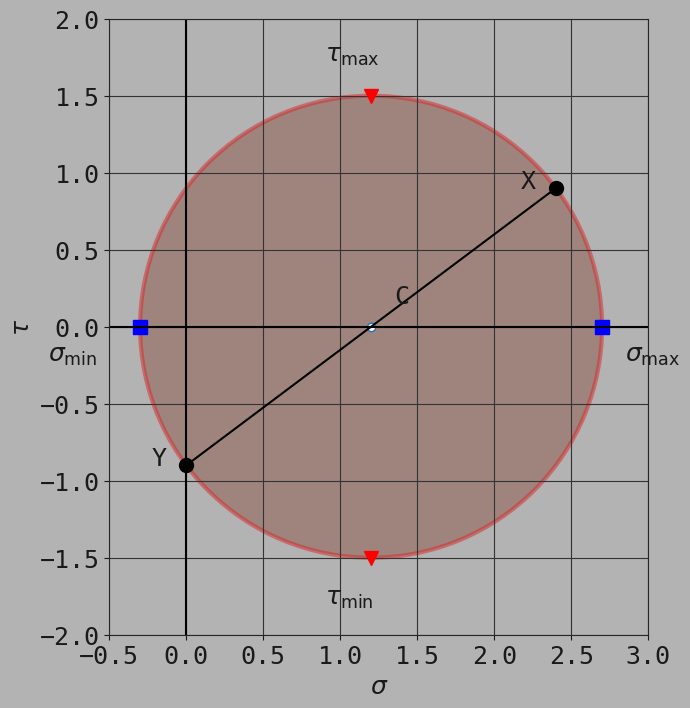

In [49]:
print('---------------------------')
print('Círculo de Mohr')
print('---------------------------')

def mohr(S,conv,limits,txt):
    fz = 10
    """Plot Mohr circle for a 2D tensor"""
    S11 = S[0][0]
    S12 = S[0][1]
    S22 = S[1][1]
    center = [(S11 + S22)/2.0, 0.0]
    radius = np.sqrt((S11 - S22)**2/4.0 + S12**2)
    Smin = center[0] - radius
    Smax = center[0] + radius
    # principal angle
    ang2tprinc = np.arctan(2*S12/(S11-S22))/2

    if txt == 1:
        if conv == 'counterclockwise':
            print(f'Ponto X ({S11:.1f},{-S12:.1f}) MPa')
            print(f'Ponto Y ({S22:.1f},{S12:.1f}) MPa\n')
        elif conv == 'clockwise':
            print(f'Ponto X ({S11:.1f},{S12:.1f}) MPa')
            print(f'Ponto Y ({S22:.1f},{-S12:.1f}) MPa\n')
        print(f'  Tensão normal mínima: {np.round(Smin,3):.1f} MPa')
        print(f'  Tensão normal mínima: {np.round(Smax,3):.1f} MPa')
        print(f'   Tensão normal média: {np.round(center[0], 3):.1f} MPa')
        print(f'Tensão de corte máxima: {np.round(radius, 3):.1f} MPa')
        print(f'Tensão de corte mínima: {np.round(-radius, 3):.1f} MPa')
        print(f'Ângulo direção principal: {np.round(np.rad2deg(ang2tprinc), 3):.1f} deg')
        print(f'(tens. corte nulas; espaço físico)')

    # plt.rcParams['axes.facecolor']='#7f7f7f'
    fig, ax = plt.subplots(figsize=(12,8))
    circ = plt.Circle((center[0],0), radius, facecolor='#8c564b', lw=3,
    edgecolor='#d62728', alpha = 0.5)
    desv = 0.1*radius
    plt.axis('image')
    ax = plt.gca()
    ax.add_artist(circ)
    ax.set_xlim(Smin - .3*radius, Smax + .3*radius)
    ax.set_ylim(-1.3*radius, 1.3*radius)
    plt.plot(Smin, 0, 'bs', markersize= fz)
    plt.plot(Smax, 0, 'bs', markersize= fz)
    plt.plot(center[0], radius, 'rv', markersize= fz)
    plt.plot(center[0], -radius, 'rv', markersize= fz)
    plt.plot(center[0], center[1], 'o', mfc='w')
    plt.text(center[0]+desv, desv, 'C')
    if conv == 'counterclockwise':
        plt.plot([S11, S22], [-S12, S12], 'ko', markersize= fz)
        plt.plot([S11, S22], [-S12, S12], 'k', markersize= fz)
        plt.text(S11 - .5*desv, -S12 , 'X')
        plt.text(S22 - .5*desv, S12, 'Y')
    elif conv == 'clockwise':
        plt.plot([S11, S22], [S12, -S12], 'ko', markersize= fz)
        plt.plot([S11, S22], [S12, -S12], 'k', markersize= fz)
        plt.text(S11 - 1.5*desv, S12 , 'X')
        plt.text(S22 - 1.5*desv, -S12, 'Y')
    plt.text(Smin - 0.4*radius, -0.15*radius, r'$\sigma_\mathrm{min}$')
    plt.text(Smax + desv, -0.15*radius, r'$\sigma_\mathrm{max}$')
    plt.text(center[0]-2*desv, 1.15*radius, r'$\tau_\mathrm{max}$')
    plt.text(center[0]-2*desv, -1.2*radius, r'$\tau_\mathrm{min}$')
    plt.xlabel(r"$\sigma$", size=18)
    plt.ylabel(r"$\tau$", size=18)
    plt.xlim(limits[0,0],limits[0,1])
    plt.ylim(limits[1,0],limits[1,1])
    ax.axhline(y=0, color='k')
    ax.axvline(x=0, color='k')
    ax.grid()
    plt.show()

S = ttH*1e-6
axislim = np.array([[-.5,3],[-2,2]])
print('\nPLANO y-z:\n')
S11 = S[0,0]
S12 = S[0,2]
S22 = S[2,2]

mohr(np.array([[S11, S12],[S12, S22]]),'clockwise',axislim, 1)

---

Copyright (c) DEMI - FCT NOVA

Interactive computing by <a href="https://jupyter.org/" target="_blank"> <span
style="color:#333399"> Jupyter Notebook </span> </a> &nbsp;|&nbsp;Coded by <a href = "mailto: jmc.xavier@fct.unl.pt">José Xavier</a>

Licensed under  <a href="http://creativecommons.org/licenses/by-sa/4.0/"
target="_blank"> <span style="color:#333399;font-size: 20px"> CC BY-SA 4.0  </span></a>